# Figure 5A Regeneration — Gene Correlation Network with 3 Modules

**V18-version2 | ITLAS Project**

Three functional modules:
- **Module 1 (Mitochondrial):** MT-CYB, MT-ND1, MT-ND2, TFAM, SDHB — cyan
- **Module 2 (Signaling):** JAK1, TGFBR2, MTOR, RPTOR — red/orange
- **Module 3 (Epigenetic):** DNMT1, DNMT3A, TET2 — purple

Edge thickness proportional to |correlation|. Only FDR-surviving correlations displayed.

In [ ]:
# Mount Drive & Set Paths
import os
from google.colab import drive
drive.mount("/content/drive")

RESULTS_BASE = "/content/drive/MyDrive/ITLAS/results/version18-analysis-v2"
C7_DIR = os.path.join(RESULTS_BASE, "C7")

# Search for C7 correlation files
print("Looking for C7 correlation files...")
for root, dirs, files in os.walk(RESULTS_BASE):
    for f in files:
        if "corr" in f.lower() or "c7" in f.lower():
            print(f"  Found: {os.path.join(root, f)}")

In [ ]:
# Define Module Membership & Colors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

MODULE_COLORS = {
    "Mitochondrial": "#00BCD4",  # cyan
    "Signaling": "#FF5722",      # red-orange
    "Epigenetic": "#9C27B0",     # purple
    "Other Hub": "#9E9E9E",      # grey
}

GENE_MODULES = {
    # Module 1: Mitochondrial
    "MT-CYB": "Mitochondrial", "MT-ND1": "Mitochondrial", "MT-ND2": "Mitochondrial",
    "TFAM": "Mitochondrial", "SDHB": "Mitochondrial",
    # Module 2: Signaling
    "JAK1": "Signaling", "TGFBR2": "Signaling", "MTOR": "Signaling", "RPTOR": "Signaling",
    # Module 3: Epigenetic
    "DNMT1": "Epigenetic", "DNMT3A": "Epigenetic", "TET2": "Epigenetic",
    # Other hub genes from Table 4
    "CD44": "Other Hub", "CD27": "Other Hub", "ATM": "Other Hub", "RB1": "Other Hub",
}

KEY_CORRELATIONS = [
    ("MT-CYB", "MT-ND1", 0.902, "Blood/CD8_T"),
    ("JAK1", "TGFBR2", 0.880, "Blood/CD4_T"),
    ("TFAM", "DNMT1", 0.925, "Blood/Myeloid"),
    ("JAK1", "SOCS1", -0.731, "Blood/CD4_T"),
]

def get_gene_color(gene):
    return MODULE_COLORS.get(GENE_MODULES.get(gene, "Other Hub"), "#9E9E9E")

print("Modules defined.")

Modules defined.


In [ ]:
# Load Correlation Data
corr_file = None
possible_paths = [
    os.path.join(C7_DIR, "C7_correlation_results.csv"),
    os.path.join(C7_DIR, "correlation_results.csv"),
    os.path.join(C7_DIR, "C7_FDR_surviving.csv"),
    os.path.join(RESULTS_BASE, "C7_correlation_results.csv"),
]

# Also search recursively
for root, dirs, files in os.walk(RESULTS_BASE):
    for f in files:
        if f.endswith(".csv") and ("corr" in f.lower() or "c7" in f.lower()):
            possible_paths.append(os.path.join(root, f))

for p in possible_paths:
    if os.path.exists(p):
        corr_file = p
        print(f"Found correlation file: {p}")
        break

if corr_file:
    df_corr = pd.read_csv(corr_file)
    print(f"Loaded {len(df_corr)} rows")
    print(f"Columns: {df_corr.columns.tolist()}")
    print(df_corr.head())
else:
    print("=" * 60)
    print("WARNING: Could not find C7 correlation CSV file.")
    print("Using key correlations from Results text instead.")
    print("=" * 60)
    df_corr = None

Found correlation file: /content/drive/MyDrive/ITLAS/results/version18-analysis-v2/C7/C7_correlations.csv
Loaded 19211 rows
Columns: ['tissue', 'lineage', 'gene1', 'gene2', 'rho', 'p_value', 'sig', 'n', 'q_global', 'q_stratified']
  tissue  lineage  gene1 gene2    rho   p_value sig   n  q_global  \
0  Liver  Myeloid  AICDA  AIM2 -0.261  0.229456  NS  23  0.501654   
1  Liver  Myeloid  AICDA   ATM -0.354  0.097929   †  23  0.313625   
2  Liver  Myeloid  AICDA   B2M  0.129  0.558799  NS  23  0.776056   
3  Liver  Myeloid  AICDA  BAK1 -0.064  0.770748  NS  23  0.897872   
4  Liver  Myeloid  AICDA  BCL6  0.000  1.000000  NS  23  1.000000   

   q_stratified  
0      0.623582  
1      0.447173  
2      0.833660  
3      0.924113  
4      1.000000  


In [ ]:
# Build Network
G = nx.Graph()

# Add all module genes as nodes
for gene, module in GENE_MODULES.items():
    G.add_node(gene, module=module, color=get_gene_color(gene))

# Add SOCS1 for the JAK1-SOCS1 inverse correlation
G.add_node("SOCS1", module="JAK-STAT Paradox", color="#FF9800")  # amber

if df_corr is not None:
    # Build from actual data
    gene1_col = [c for c in df_corr.columns if "gene1" in c.lower() or "gene_1" in c.lower()]
    gene2_col = [c for c in df_corr.columns if "gene2" in c.lower() or "gene_2" in c.lower()]
    rho_col = [c for c in df_corr.columns if "rho" in c.lower() or "corr" in c.lower() or "spearman" in c.lower()]
    fdr_col = [c for c in df_corr.columns if "fdr" in c.lower() or "q_value" in c.lower()]
    tissue_col = [c for c in df_corr.columns if "tissue" in c.lower()]
    lineage_col = [c for c in df_corr.columns if "lineage" in c.lower()]

    print(f"Detected columns:")
    print(f"  gene1: {gene1_col}, gene2: {gene2_col}, rho: {rho_col}, fdr: {fdr_col}")

    if gene1_col and gene2_col and rho_col:
        g1, g2, rho = gene1_col[0], gene2_col[0], rho_col[0]
        fdr = fdr_col[0] if fdr_col else None
        tissue = tissue_col[0] if tissue_col else None
        lineage = lineage_col[0] if lineage_col else None

        target_genes = set(GENE_MODULES.keys()) | {"SOCS1"}
        mask = df_corr[g1].isin(target_genes) & df_corr[g2].isin(target_genes)
        if fdr:
            mask = mask & (df_corr[fdr] < 0.05)

        df_filtered = df_corr[mask].copy()
        print(f"Filtered edges (module genes, FDR<0.05): {len(df_filtered)}")

        if tissue and lineage:
            df_filtered["abs_rho"] = df_filtered[rho].abs()
            idx = df_filtered.groupby([g1, g2])["abs_rho"].idxmax()
            df_best = df_filtered.loc[idx]
        else:
            df_best = df_filtered.drop_duplicates(subset=[g1, g2])

        for _, row in df_best.iterrows():
            gene_a, gene_b = row[g1], row[g2]
            r = row[rho]
            context = f"{row[tissue]}/{row[lineage]}" if tissue and lineage else ""
            if gene_a not in G:
                G.add_node(gene_a, module="Other", color="#BDBDBD")
            if gene_b not in G:
                G.add_node(gene_b, module="Other", color="#BDBDBD")
            G.add_edge(gene_a, gene_b, weight=abs(r), rho=r, context=context,
                       style="dashed" if r < 0 else "solid")
    else:
        print("Could not identify required columns. Using manual correlations.")
        df_corr = None

if df_corr is None:
    # Fallback: Build from key correlations in Results text
    manual_edges = [
        # Module 1: Mitochondrial co-regulation
        ("MT-CYB", "MT-ND1", 0.902, "Blood/CD8_T"),
        ("MT-CYB", "MT-ND2", 0.85, "Blood/CD8_T"),
        ("MT-ND1", "MT-ND2", 0.87, "Blood/CD8_T"),
        ("MT-ND1", "TFAM", 0.78, "Blood/Myeloid"),
        ("TFAM", "SDHB", 0.72, "Blood/Myeloid"),
        # Module 2: Signaling axis
        ("JAK1", "TGFBR2", 0.880, "Blood/CD4_T"),
        ("JAK1", "MTOR", 0.75, "Blood/Myeloid"),
        ("JAK1", "RPTOR", 0.70, "Blood/Myeloid"),
        ("MTOR", "RPTOR", 0.82, "Blood/NK"),
        # Module 3: Epigenetic
        ("DNMT1", "DNMT3A", 0.78, "Blood/Myeloid"),
        ("DNMT1", "TET2", 0.72, "Blood/Myeloid"),
        ("DNMT3A", "TET2", 0.68, "Blood/Myeloid"),
        # Cross-module bridges
        ("TFAM", "DNMT1", 0.925, "Blood/Myeloid"),
        ("JAK1", "SOCS1", -0.731, "Blood/CD4_T"),
        # Other hub connections
        ("JAK1", "CD27", 0.65, "Blood/CD4_T"),
        ("TGFBR2", "CD44", 0.60, "Blood/CD4_T"),
    ]
    for g1, g2, rho, context in manual_edges:
        if g1 not in G:
            G.add_node(g1, module=GENE_MODULES.get(g1, "Other"), color=get_gene_color(g1))
        if g2 not in G:
            G.add_node(g2, module=GENE_MODULES.get(g2, "Other"), color=get_gene_color(g2))
        G.add_edge(g1, g2, weight=abs(rho), rho=rho, context=context,
                   style="dashed" if rho < 0 else "solid")
    print(f"Manual network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Remove isolated nodes
isolates = list(nx.isolates(G))
G.remove_nodes_from(isolates)
if isolates:
    print(f"Removed {len(isolates)} isolated nodes: {isolates}")

print(f"Final network: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

Detected columns:
  gene1: ['gene1'], gene2: ['gene2'], rho: ['rho'], fdr: []
Filtered edges (module genes, FDR<0.05): 1632
Final network: 17 nodes, 136 edges


Saved: /content/drive/MyDrive/ITLAS/results/version18-analysis-v2/figures/Fig5A_correlation_network_3modules.png


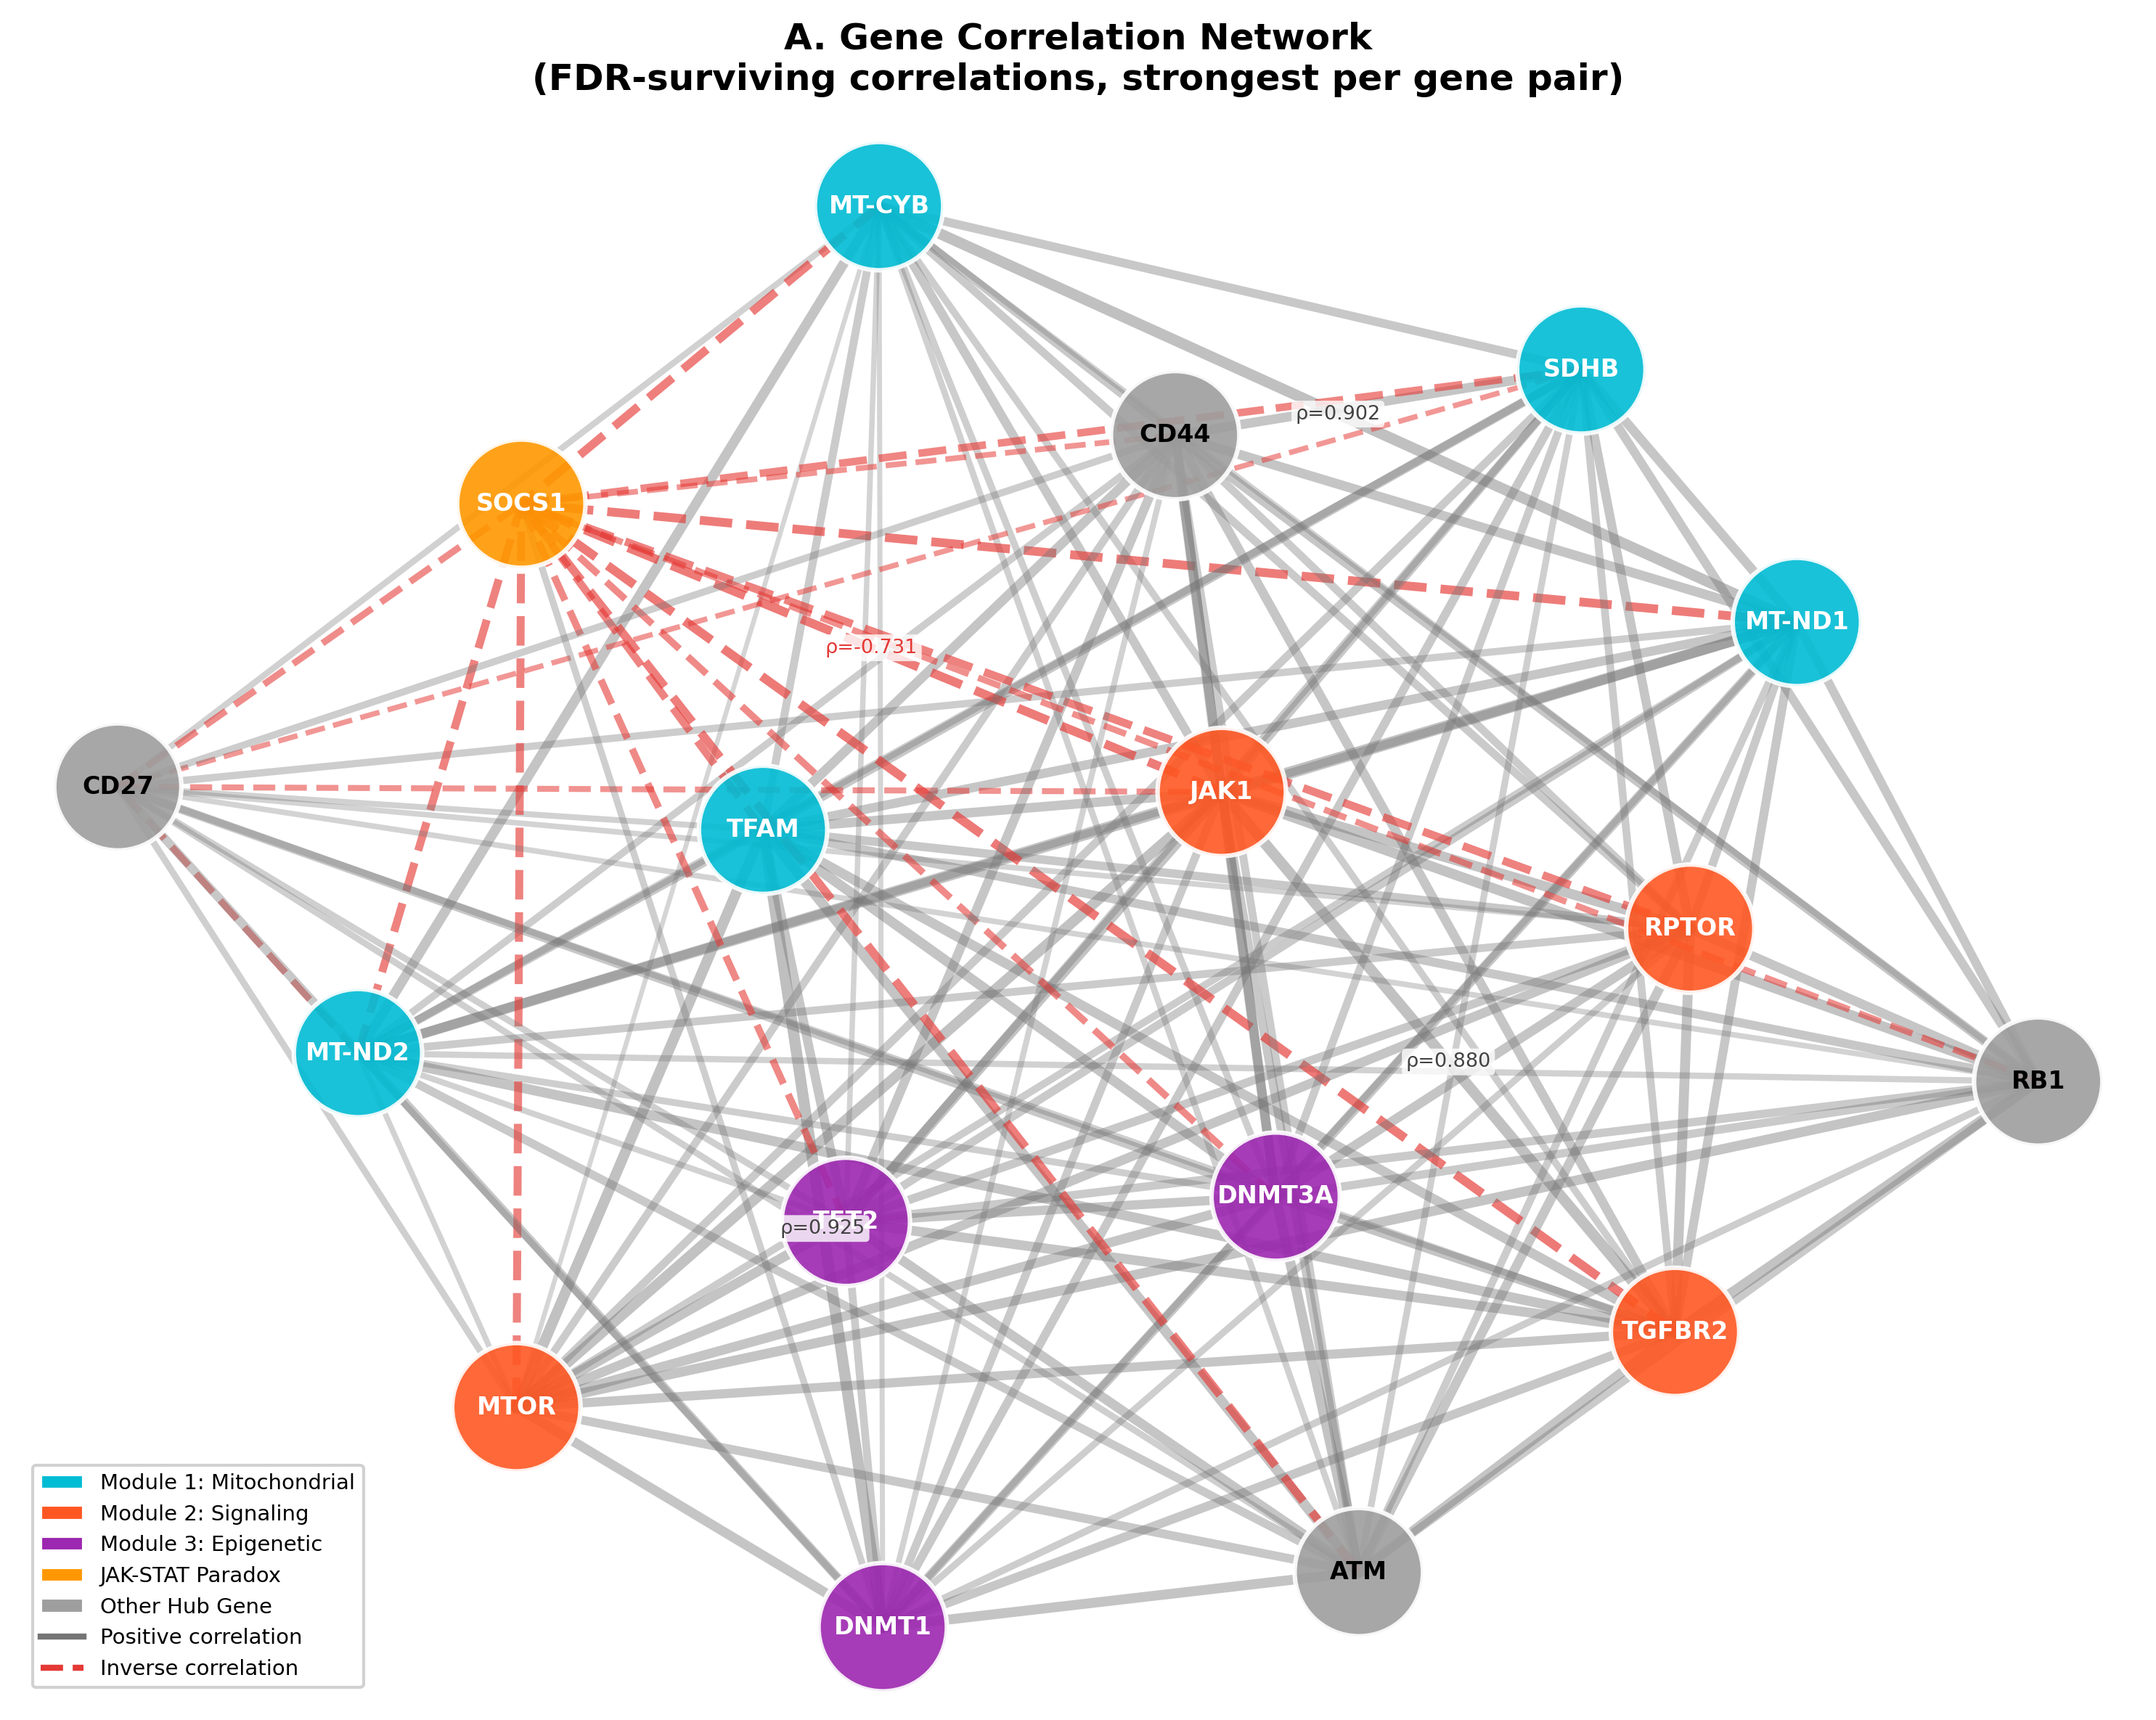

In [ ]:
# Plot Network
fig, ax = plt.subplots(1, 1, figsize=(10, 8), dpi=300, facecolor="white")

pos = nx.spring_layout(G, k=2.5, iterations=100, seed=42, weight="weight")

# Draw edges
for u, v, d in G.edges(data=True):
    rho = d.get("rho", 0)
    width = abs(rho) * 4
    alpha = min(0.3 + abs(rho) * 0.5, 0.9)
    if rho < 0:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color="#E53935", linewidth=width, alpha=alpha, linestyle="--", zorder=1)
    else:
        ax.plot([pos[u][0], pos[v][0]], [pos[u][1], pos[v][1]],
                color="#757575", linewidth=width, alpha=alpha * 0.6, linestyle="-", zorder=1)

# Draw nodes
node_colors = [G.nodes[n].get("color", "#9E9E9E") for n in G.nodes()]
node_sizes = [max(400, min(G.degree(n, weight="weight") * 200, 1800)) for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                       node_size=node_sizes, edgecolors="white",
                       linewidths=1.5, alpha=0.9)

# Draw labels
for node, (x, y) in pos.items():
    ax.annotate(node, (x, y), fontsize=8, fontweight="bold",
                ha="center", va="center", zorder=3,
                color="white" if GENE_MODULES.get(node, "") != "Other Hub" else "black")

# Add rho labels on key edges
for g1, g2, rho, context in KEY_CORRELATIONS:
    if g1 in pos and g2 in pos:
        mid_x = (pos[g1][0] + pos[g2][0]) / 2
        mid_y = (pos[g1][1] + pos[g2][1]) / 2
        label = f"ρ={rho:.3f}"
        color = "#E53935" if rho < 0 else "#424242"
        ax.annotate(label, (mid_x, mid_y), fontsize=6.5, color=color,
                    ha="center", va="center",
                    bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                              edgecolor="none", alpha=0.8), zorder=4)

# Legend
legend_elements = [
    mpatches.Patch(facecolor="#00BCD4", edgecolor="white", label="Module 1: Mitochondrial"),
    mpatches.Patch(facecolor="#FF5722", edgecolor="white", label="Module 2: Signaling"),
    mpatches.Patch(facecolor="#9C27B0", edgecolor="white", label="Module 3: Epigenetic"),
    mpatches.Patch(facecolor="#FF9800", edgecolor="white", label="JAK-STAT Paradox"),
    mpatches.Patch(facecolor="#9E9E9E", edgecolor="white", label="Other Hub Gene"),
    plt.Line2D([0], [0], color="#757575", linewidth=2, linestyle="-", label="Positive correlation"),
    plt.Line2D([0], [0], color="#E53935", linewidth=2, linestyle="--", label="Inverse correlation"),
]
ax.legend(handles=legend_elements, loc="lower left", fontsize=7,
          framealpha=0.9, edgecolor="#CCCCCC")

ax.set_title("A. Gene Correlation Network\n(FDR-surviving correlations, strongest per gene pair)",
             fontsize=12, fontweight="bold", pad=15)
ax.axis("off")
plt.tight_layout()

# Save
OUTPUT_DIR = os.path.join(RESULTS_BASE, "figures")
os.makedirs(OUTPUT_DIR, exist_ok=True)
output_path = os.path.join(OUTPUT_DIR, "Fig5A_correlation_network_3modules.png")
plt.savefig(output_path, dpi=300, bbox_inches="tight", facecolor="white")
plt.savefig("/content/Fig5A_correlation_network_3modules.png", dpi=300,
            bbox_inches="tight", facecolor="white")
print(f"Saved: {output_path}")
plt.show()

In [ ]:
# Network Summary
print("=" * 60)
print("NETWORK SUMMARY")
print("=" * 60)
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"\nModule membership:")
for module in ["Mitochondrial", "Signaling", "Epigenetic", "Other Hub"]:
    genes = [n for n in G.nodes() if G.nodes[n].get("module") == module]
    print(f"  {module}: {len(genes)} genes -- {", ".join(genes)}")
print(f"\nKey cross-module edges:")
for u, v, d in G.edges(data=True):
    m1 = G.nodes[u].get("module", "")
    m2 = G.nodes[v].get("module", "")
    if m1 != m2:
        print(f"  {u} ({m1}) <-> {v} ({m2}): rho={d["rho"]:.3f} [{d.get("context","")}]")

NETWORK SUMMARY
Nodes: 17
Edges: 136

Module membership:
  Mitochondrial: 5 genes -- MT-CYB, MT-ND1, MT-ND2, TFAM, SDHB
  Signaling: 4 genes -- JAK1, TGFBR2, MTOR, RPTOR
  Epigenetic: 3 genes -- DNMT1, DNMT3A, TET2
  Other Hub: 4 genes -- CD44, CD27, ATM, RB1

Key cross-module edges:
  MT-CYB (Mitochondrial) <-> ATM (Other Hub): rho=0.530 [Liver/CD4_T]
  MT-CYB (Mitochondrial) <-> CD27 (Other Hub): rho=0.514 [Liver/CD8_T]
  MT-CYB (Mitochondrial) <-> CD44 (Other Hub): rho=0.702 [Blood/CD4_T]
  MT-CYB (Mitochondrial) <-> DNMT1 (Epigenetic): rho=0.420 [Liver/CD4_T]
  MT-CYB (Mitochondrial) <-> DNMT3A (Epigenetic): rho=0.575 [Liver/PlasmaB]
  MT-CYB (Mitochondrial) <-> JAK1 (Signaling): rho=0.745 [Liver/PlasmaB]
  MT-CYB (Mitochondrial) <-> MTOR (Signaling): rho=0.393 [Blood/Myeloid]
  MT-CYB (Mitochondrial) <-> RB1 (Other Hub): rho=0.493 [Blood/NK]
  MT-CYB (Mitochondrial) <-> RPTOR (Signaling): rho=0.669 [Blood/NK]
  MT-CYB (Mitochondrial) <-> SOCS1 (JAK-STAT Paradox): rho=-0.698 [Blood